In [2]:
!pip install folium


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
print(sys.executable)

C:\Users\user\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
!{sys.executable} -m pip install folium


  Using cached folium-0.19.5-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached branca-0.8.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached xyzservices-2025.1.0-py3-none-any.whl.metadata (4.3 kB)
Using cached folium-0.19.5-py2.py3-none-any.whl (110 kB)
Using cached branca-0.8.1-py3-none-any.whl (26 kB)
Using cached xyzservices-2025.1.0-py3-none-any.whl (88 kB)


In [2]:
!pip install wordcloud


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install folium wordcloud

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import folium
from wordcloud import WordCloud


In [3]:
# Replace with your actual file path
df = pd.read_csv("job_descriptions.csv")

# Display top rows
df.head()


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [4]:
# Check for nulls in important columns
df[['Job Title', 'skills', 'Salary Range', 'location', 'Job Posting Date']].isnull().sum()

# Drop rows where Skills or Job Title is missing
df = df.dropna(subset=['skills', 'Job Title'])

# Fill missing values where necessary
df['Salary Range'] = df['Salary Range'].fillna("0-0")


C:\Users\user\AppData\Local\Temp\ipykernel_16404\1878355474.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(skills), y=list(counts), palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_16404\1878355474.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


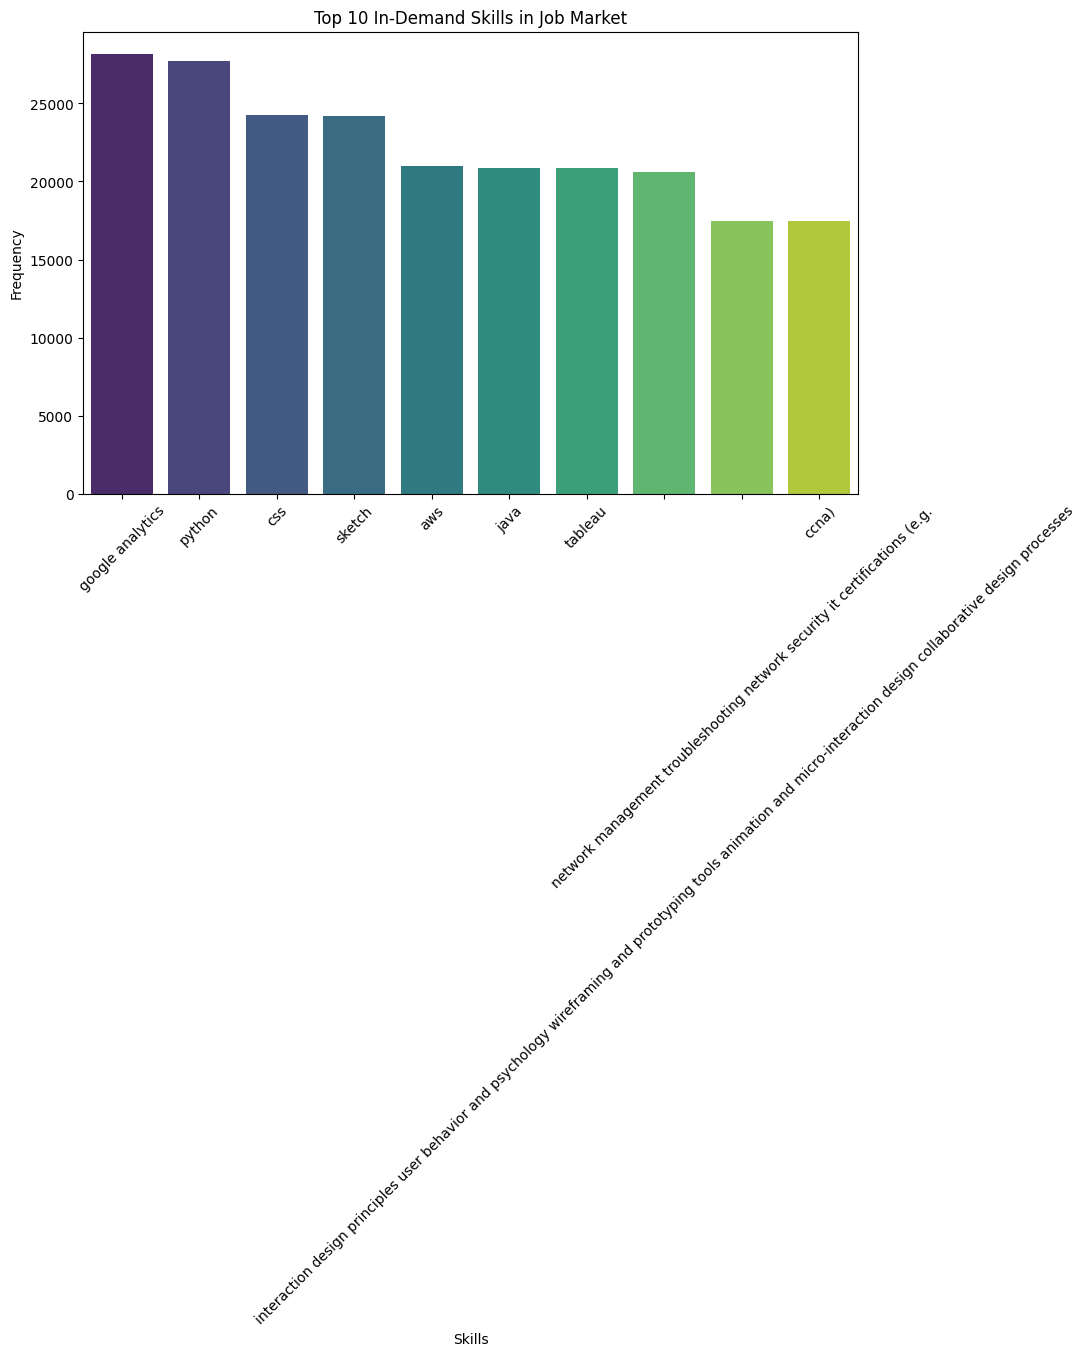

In [5]:
# Split skills and count frequency
all_skills = df['skills'].dropna().str.lower().str.split(', ')
skill_counts = Counter([skill for skills in all_skills for skill in skills])
most_common_skills = skill_counts.most_common(10)

# Bar chart
skills, counts = zip(*most_common_skills)
plt.figure(figsize=(10,6))
sns.barplot(x=list(skills), y=list(counts), palette='viridis')
plt.title("Top 10 In-Demand Skills in Job Market")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.xlabel("Skills")
plt.tight_layout()
plt.show()


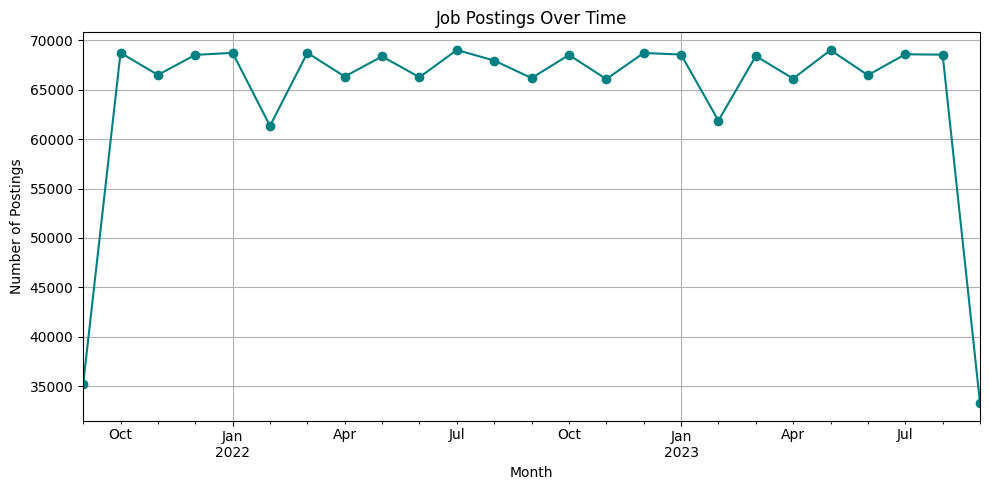

In [6]:
df['Job Posting Date'] = pd.to_datetime(df['Job Posting Date'], errors='coerce')
df['Month'] = df['Job Posting Date'].dt.to_period('M')

# Count job titles per month
job_trends = df.groupby('Month')['Job Title'].count()

# Plot
job_trends.plot(kind='line', figsize=(10,5), marker='o', color='teal')
plt.title("Job Postings Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Postings")
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
from folium.plugins import MarkerCluster

map_df = df.dropna(subset=['latitude', 'longitude'])

# Sample just a manageable number
map_df_sample = map_df.sample(n=1000, random_state=42)

map_jobs = folium.Map(location=[map_df_sample['latitude'].mean(), map_df_sample['longitude'].mean()], zoom_start=2)
marker_cluster = MarkerCluster().add_to(map_jobs)

for _, row in map_df_sample.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=row['Job Title']
    ).add_to(marker_cluster)

map_jobs


In [14]:
def estimate_salary(title):
    title = title.lower()
    if 'developer' in title or 'engineer' in title:
        return 90000
    elif 'manager' in title:
        return 80000
    elif 'designer' in title:
        return 70000
    elif 'teacher' in title:
        return 50000
    else:
        return 60000

df['avg_salary'] = df['Job Title'].apply(estimate_salary)


In [20]:
# Extract average salary from 'Salary Range'
def extract_avg_salary(s):
    try:
        parts = s.replace(',', '').split('-')
        parts = list(map(int, parts))
        return sum(parts) / 2 if len(parts) == 2 else int(parts[0])
    except:
        return None

df['avg_salary'] = df['Salary Range'].apply(extract_avg_salary)

# Count skills
df['skill_count'] = df['skills'].apply(lambda x: len(x.split(',')) if pd.notnull(x) else 0)

# Fill NaN salaries with 0 (optional: or drop them)
df['avg_salary'] = df['avg_salary'].fillna(0)

# Avoid division by zero or NaN
max_salary = df['avg_salary'].max()
max_skills = df['skill_count'].max()

# Avoid dividing by 0
if max_salary == 0: max_salary = 1
if max_skills == 0: max_skills = 1

# Compute normalized score
df['job_value_score'] = (
    df['avg_salary'] / max_salary +
    df['skill_count'] / max_skills
)


C:\Users\user\AppData\Local\Temp\ipykernel_16404\4114147019.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['avg_salary'] = df['avg_salary'].fillna(0)


In [26]:
df['job_value_score'] = (
    (df['avg_salary'] / max_salary) +
    (df['skill_count'] / max_skills)
)

# Normalize the final score between 0 and 1
df['job_value_score'] = (
    df['job_value_score'] - df['job_value_score'].min()
) / (df['job_value_score'].max() - df['job_value_score'].min())


In [27]:
df[['Job Title', 'avg_salary', 'skill_count', 'job_value_score']].head()


,Job Title,avg_salary,skill_count,job_value_score
0,Digital Marketing Specialist,None,4,NaN
1,Web Developer,None,5,NaN
2,Operations Manager,None,2,NaN
3,Network Engineer,None,1,NaN
4,Event Manager,None,1,NaN


In [38]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Example: Load your data here
# df = pd.read_csv("your_file.csv")

# --- Step 1: Extract average salary from ranges like "$59K-$99K"
def extract_avg_salary(s):
    if pd.isna(s) or '-' not in s:
        return 0
    try:
        parts = s.replace('$', '').replace('K', '').split('-')
        low, high = map(int, parts)
        return ((low + high) / 2) * 1000  # Convert to full salary
    except:
        return 0

df['avg_salary'] = df['Salary Range'].apply(extract_avg_salary)

# --- Step 2: Count skills
df['skill_count'] = df['skills'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

# --- Step 3: Normalize avg_salary and skill_count
scaler = MinMaxScaler()
df[['norm_salary', 'norm_skills']] = scaler.fit_transform(df[['avg_salary', 'skill_count']])

# --- Step 4: Calculate job value score
df['job_value_score'] = df['norm_salary'] + df['norm_skills']

# --- Step 5: Display selected columns
result = df[['Job Title', 'avg_salary', 'skill_count', 'job_value_score']]
print(result.head(10))


                      Job Title  avg_salary  skill_count  job_value_score
0  Digital Marketing Specialist     79000.0           21         0.900575
1                 Web Developer     86000.0           11         0.789080
2            Operations Manager     82500.0           25         1.155172
3              Network Engineer     78000.0           22         0.901724
4                 Event Manager     75500.0           13         0.508046
5               Software Tester     76000.0           17         0.662644
6                       Teacher     83000.0           10         0.654598
7                UX/UI Designer     83500.0           23         1.119540
8                UX/UI Designer     83500.0           18         0.947126
9               Wedding Planner     70000.0            6         0.083333


In [ ]:
text = " ".join(desc for desc in df['Job Description'].dropna())

# Generate WordCloud
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top Keywords in Job Descriptions", fontsize=18)
plt.show()
